# Remaining Useful Life of Battery (RUL)

Goal: Predicting Useful Life that is to find the number of cycles left before capacity drops below threshold. 

RUL: How many more discharge cycle remain until the battery degreades below threshold like 80% of initial capacity.



`Importing Required Libraries`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from numpy.polynomial import Polynomial


## Loading, Filtering from Metadata CSV

In [2]:
#load metadata
meta = pd.read_csv("../nasa_battery_dataset/metadata.csv")

#filter only discharge rows with valid capacity
discharge_meta = meta[(meta['type'] =="discharge") & (meta['Capacity'].notnull())].copy()

#sort by test order
discharge_meta = discharge_meta.sort_values(by='test_id').reset_index(drop=True)

## Computing Remaining Useful Life

From Metadata, values for ML target

In [3]:
# Convert Capacity column to numeric again to be sure that it is int or float
discharge_meta['Capacity'] = pd.to_numeric(discharge_meta['Capacity'], errors='coerce')

#use first capacity as reference (full capacity)
initial_capacity = float (discharge_meta['Capacity'].iloc[0])
threshold = 0.8 * initial_capacity
#RUL is how many discharge cycles are left until capacity drops below threshold
rul=[]
#loop through each discharge cycle
for i in range(len(discharge_meta)):
    future_capacities = discharge_meta['Capacity'].iloc[i:]
    below_threshold = future_capacities < threshold

    #if remaining capacity is below threshold, RUL is 0
    if below_threshold.any():
        drop_index = below_threshold.idxmax() #find the index of the first cycle below threshold
        rul_value = drop_index - i
    else:
        rul_value = 0 #if no cycles below threshold, RUL is 0
    rul.append(rul_value)

#add RUL to the original DataFrame
discharge_meta['RUL'] = rul
# Add Cycle number (1-based index)
discharge_meta['Cycle'] = range(1, len(discharge_meta) + 1)

#save the DataFrame with RUL to a new CSV file
print (discharge_meta[['Cycle', 'Capacity', 'RUL']])
discharge_meta.to_csv('../nasa_battery_dataset/processed/discharge_meta_with_rul.csv', index=False)

      Cycle  Capacity  RUL
0         1  1.674305    2
1         2  1.728239    1
2         3  0.673463    0
3         4  0.785278    0
4         5  0.863145    0
...     ...       ...  ...
2789   2790  1.309015    0
2790   2791  1.421787    1
2791   2792  1.325079    0
2792   2793  1.432455    1
2793   2794  1.185675    0

[2794 rows x 3 columns]


`Visualize Battery Degradation and RUL`

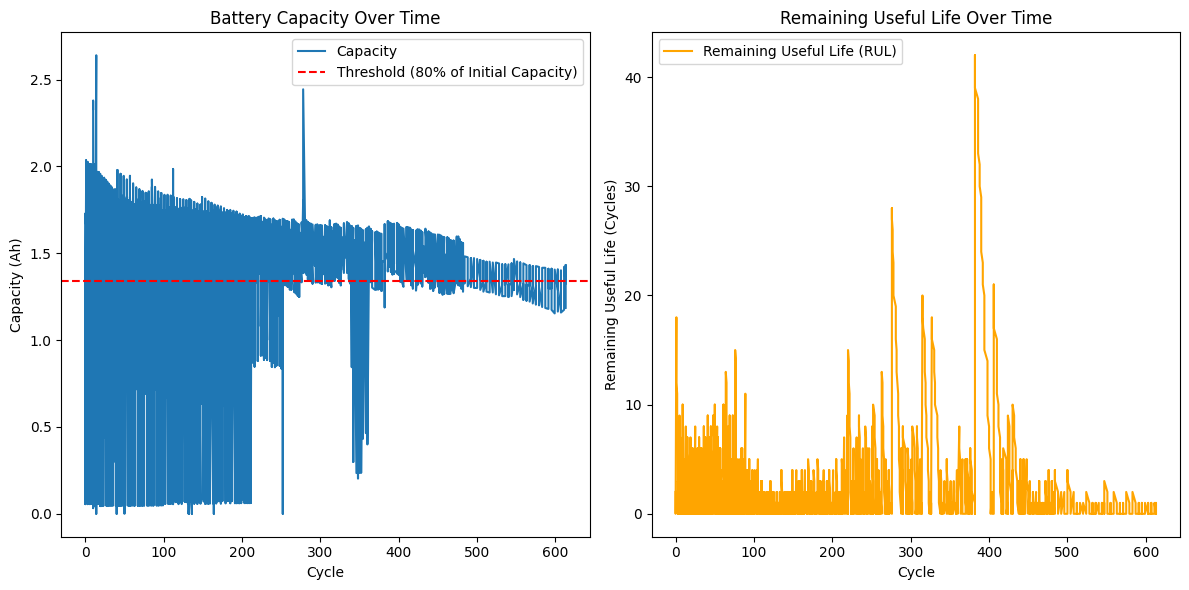

In [4]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(discharge_meta['test_id'], discharge_meta['Capacity'], label='Capacity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (80% of Initial Capacity)')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title('Battery Capacity Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(discharge_meta['test_id'], discharge_meta['RUL'], label='Remaining Useful Life (RUL)', color='orange')
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.title('Remaining Useful Life Over Time')
plt.legend()
plt.tight_layout()
plt.show()

`Interpretation of left Graph`

The graph likely starts at full capacity and gradually decreases as the battery goes through more cycles. 

When the blue line crosses the red dashed line, the battery has degraded below 80% of its original capacity - a typical end-of-life (EoL) defination in battery studies.

`Interpretation of right Graph`

The RUL starts high sign of healthy battery. As the battery degrades over time, the RUL decreases gradually. 

Eventually, RUL reaches 0 - meaning the battery has dropped below 80% capacity at that point or will do so very soon. 

